In [1]:
from rdkit import Chem

def extract_edge_attributes(smiles_string):
    # 1. Parse the SMILES string into an RDKit molecule object
    # Chem.AddHs(mol) can be used if you want to explicitly include Hydrogen edges
    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return "Invalid SMILES string"

    print(f"Molecule: {smiles_string}")
    print("-" * 60)

    # 2. Iterate through all bonds (edges) in the molecule
    for bond in mol.GetBonds():
        # Get index of the two atoms connected by this edge
        begin_atom_idx = bond.GetBeginAtomIdx()
        end_atom_idx = bond.GetEndAtomIdx()
        begin_atom_symbol = bond.GetBeginAtom().GetSymbol()
        end_atom_symbol = bond.GetEndAtom().GetSymbol()

        # 3. Extract your exact dataset attributes
        edge_type = str(bond.GetBondType())       # SINGLE, DOUBLE, TRIPLE, AROMATIC
        bond_order = bond.GetBondTypeAsDouble()   # 1.0, 2.0, 3.0, 1.5
        is_aromatic = bond.GetIsAromatic()        # True / False
        is_in_ring = bond.IsInRing()              # True / False
        is_conjugated = bond.GetIsConjugated()    # True / False
        stereo_type = str(bond.GetStereo())       # STEREONONE, STEREOE, STEREOZ, etc.

        # 4. Print the extracted features for this edge
        print(f"Edge: {begin_atom_symbol}(idx:{begin_atom_idx}) <---> {end_atom_symbol}(idx:{end_atom_idx})")
        print(f"  └─ Edge Type:    {edge_type}")
        print(f"  └─ Bond Order:   {bond_order}")
        print(f"  └─ Aromatic:     {is_aromatic}")
        print(f"  └─ Ring:         {is_in_ring}")
        print(f"  └─ Conjugated:   {is_conjugated}")
        print(f"  └─ Stereo:       {stereo_type}")
        print("-" * 60)

In [2]:
# --- Test the function ---
# Using the Fumaric Acid example from earlier (contains stereo, conjugation, single/double bonds)
test_smiles = "O=C(O)/C=C/C(=O)O"  # smiles string
extract_edge_attributes(test_smiles)

Molecule: O=C(O)/C=C/C(=O)O
------------------------------------------------------------
Edge: O(idx:0) <---> C(idx:1)
  └─ Edge Type:    DOUBLE
  └─ Bond Order:   2.0
  └─ Aromatic:     False
  └─ Ring:         False
  └─ Conjugated:   True
  └─ Stereo:       STEREONONE
------------------------------------------------------------
Edge: C(idx:1) <---> O(idx:2)
  └─ Edge Type:    SINGLE
  └─ Bond Order:   1.0
  └─ Aromatic:     False
  └─ Ring:         False
  └─ Conjugated:   True
  └─ Stereo:       STEREONONE
------------------------------------------------------------
Edge: C(idx:1) <---> C(idx:3)
  └─ Edge Type:    SINGLE
  └─ Bond Order:   1.0
  └─ Aromatic:     False
  └─ Ring:         False
  └─ Conjugated:   True
  └─ Stereo:       STEREONONE
------------------------------------------------------------
Edge: C(idx:3) <---> C(idx:4)
  └─ Edge Type:    DOUBLE
  └─ Bond Order:   2.0
  └─ Aromatic:     False
  └─ Ring:         False
  └─ Conjugated:   True
  └─ Stereo:       STEREOE

Draw the molecule if the smile string is given

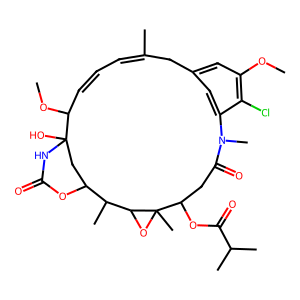

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

smiles = "COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2"   # benzene

mol = Chem.MolFromSmiles(smiles)

display(Draw.MolToImage(mol))

Bioavailability Radar

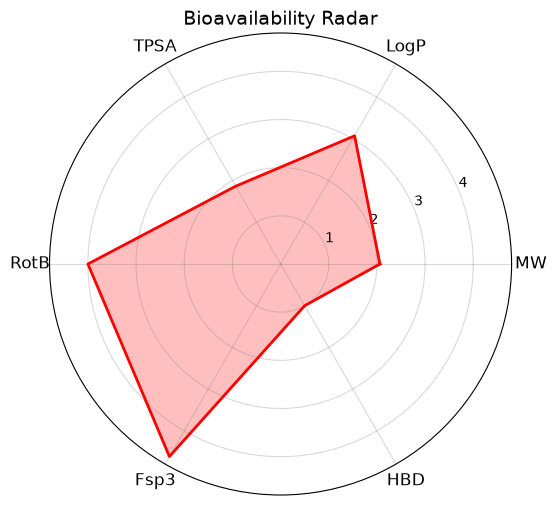

In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski
import matplotlib.pyplot as plt
import numpy as np

# SMILES
smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
mol = Chem.MolFromSmiles(smiles)

# Compute descriptors
mw = Descriptors.MolWt(mol)
logp = Crippen.MolLogP(mol)
tpsa = Descriptors.TPSA(mol)
rot_bonds = Lipinski.NumRotatableBonds(mol)
fsp3 = Lipinski.FractionCSP3(mol)
hbd = Lipinski.NumHDonors(mol)

labels = ['MW', 'LogP', 'TPSA', 'RotB', 'Fsp3', 'HBD']
values = [mw/100, logp, tpsa/20, rot_bonds, fsp3*10, hbd]

# Close the radar
values += values[:1]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# WHITE STYLE
fig, ax = plt.subplots(
    figsize=(6,6),
    subplot_kw=dict(polar=True),
    facecolor="white"
)

ax.set_facecolor("white")

# Radar line
ax.plot(angles, values, color="red", linewidth=2)

# Fill
ax.fill(angles, values, color="red", alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, color="black", fontsize=12)

# Grid styling
ax.grid(color="gray", alpha=0.3)

# Title
plt.title("Bioavailability Radar", color="black", fontsize=14)

plt.show()

get smiles from nci1

In [6]:
from rdkit import Chem
import networkx as nx

print('Loading NCI1 dataset')

graphs = []
y = []
smiles_list = []

filepath = "datasets/NCI_full/1total-connect.sdf"

supplier = Chem.SDMolSupplier(filepath, removeHs=False)

for mol in supplier:
    if mol is None:
        continue

    # Convert molecule to SMILES
    smiles = Chem.MolToSmiles(mol)

    G = nx.Graph()

    # Add atoms as nodes
    for atom in mol.GetAtoms():
        G.add_node(
            atom.GetIdx(),
            label=atom.GetSymbol()
        )

    # Add bonds as edges
    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
            bond_order=bond.GetBondTypeAsDouble(),
            aromatic=bond.GetIsAromatic(),
            in_ring=bond.IsInRing(),
            conjugated=bond.GetIsConjugated(),
            stereo=str(bond.GetStereo())
        )

    # Graph label
    label = int(float(mol.GetProp("value")))

    graphs.append(G)
    y.append(label)
    smiles_list.append(smiles)

print(f"Loaded {len(graphs)} graphs")
print(f"Loaded {len(smiles_list)} SMILES strings")

# Example
print(smiles_list[0])

Loading NCI1 dataset


[15:05:11] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[15:05:11] ERROR: Could not sanitize molecule ending on line 5976
[15:05:11] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[15:05:11] Explicit valence for atom # 0 Br, 1, is greater than permitted
[15:05:11] ERROR: Could not sanitize molecule ending on line 9488
[15:05:11] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[15:05:11] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[15:05:11] ERROR: Could not sanitize molecule ending on line 12926
[15:05:11] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[15:05:11] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[15:05:11] ERROR: Could not sanitize molecule ending on line 13981
[15:05:11] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[15:05:11] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[15:05:11] ERROR: Could not sanitize mol

Loaded 36937 graphs
Loaded 36937 SMILES strings
COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2


In [8]:
print(len(y))
print(len(smiles_list))

36937
36937


In [10]:
print(y[7000])
print(smiles_list[7000])

-1
Cc1ccsc1C(=S)Nc1ccc(Cl)c(C(=O)OC(C(C)C)C(C)C)c1
